# EDA 02 — Variable Distributions

**Goal:** Understand the shape of the data before modeling. Distributions determine the choice of transformations, loss functions, and imputation strategies. A wrong assumption about the distribution = a model trained on bad data.

**Tables:** gold_card_features, gold_price_features (latest snapshot), silver_cards (colors, types)

**Method:** Exploratory charts — histograms, violin plots, boxplots. No formal statistical tests (this is EDA, not CDA). Formal distribution tests → notebook statistical_properties/01.

**Absorbs:** pipeline_validation/eda_02_price_distribution, pipeline_validation/eda_05_card_taxonomy, exploratory_modeling/02_price_distribution

---
## Questions to answer
1. What is the shape of the EUR price distribution? Does log-transformation normalize it sufficiently?
2. What do the distributions of numerical features look like — are there outliers requiring capping?
3. How are cards distributed by rarity, color, type, and set type?
4. How large is the foil premium and does it differ between rarities?
5. Are EUR/USD/Cardmarket prices consistent across markets?

In [1]:
import duckdb
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import pandas as pd

In [2]:
# Connect to Gold and Silver databases (read-only to prevent accidental writes).
# Gold contains pre-computed features; Silver contains raw card attributes (colors, types, supertypes)
# that were not promoted to Gold because they require JSON parsing at query time.
gold_connection = duckdb.connect("../../data/gold/cards.duckdb", read_only=True)
silver_connection = duckdb.connect("../../data/silver/cards.duckdb", read_only=True)

In [3]:
# Load the working dataset: one row per unique card in the latest price snapshot.
# Joining gold_card_features (static card attributes) with gold_price_features (daily prices).
# Filter: eur IS NOT NULL — we only model cards with a known EUR price.
# Filter: latest snapshot only — avoids duplicating cards across historical dates.
gold_data_df = gold_connection.execute("""
    SELECT cf.uuid, cf.name, cf.rarity, cf.set_code, cf.set_type, cf.mana_value,
        cf.is_reserved, cf.is_reprint, cf.color_count, cf.print_count,
        cf.format_count, cf.finish_count, cf.edhrec_saltiness,
        pf.edhrec_rank, pf.eur, pf.eur_foil, pf.foil_premium, pf.usd,
        pf.cardmarket_eur, pf.days_since_last_real_price
    FROM gold_card_features cf
    JOIN gold_price_features pf ON cf.uuid = pf.uuid
    WHERE pf.eur IS NOT NULL
    AND pf.snapshot_date = (SELECT MAX(snapshot_date) FROM gold_price_features)
""").df()

In [4]:
# Add log1p(eur) as the target variable for all subsequent analysis.
# log1p(x) = log(1 + x): defined at x=0, stable for sub-cent prices, inverse is expm1().
gold_data_df["log_eur"] = np.log1p(gold_data_df["eur"])

In [5]:
# Sanity check: confirm expected row count (82k cards in latest snapshot).
print(
    f"Loaded {len(gold_data_df):,} rows, {gold_data_df['uuid'].nunique():,} unique cards"
)

Loaded 79,155 rows, 79,155 unique cards


## 1. EUR Price Distribution — Linear vs Logarithmic

**Method:** Two side-by-side histograms: eur (linear scale) and log1p(eur).

**Why:** MTG prices follow a power-law distribution — 99% of cards cost <€5, while a few cards cost >€10,000. A linear regression model on raw prices would be dominated by cheap cards. log1p(x) = log(x+1) compresses the tail, approximating a normal distribution.

⚠️ **Key standardization decision:** This project uses `log1p` (not `log10`). The difference:
- `log1p(0.01) ≈ 0.01` (a 1-cent card)
- `log10(0.01) = -2` (same card, different scale)
- `log1p` is gentler for small values and has the exact inverse `expm1`
- **Use `log1p`/`expm1` consistently in ALL subsequent notebooks**

**Interpretation:** If log1p(eur) looks symmetric → transformation is effective, can model directly. If still skewed → check tier segmentation in section 7.

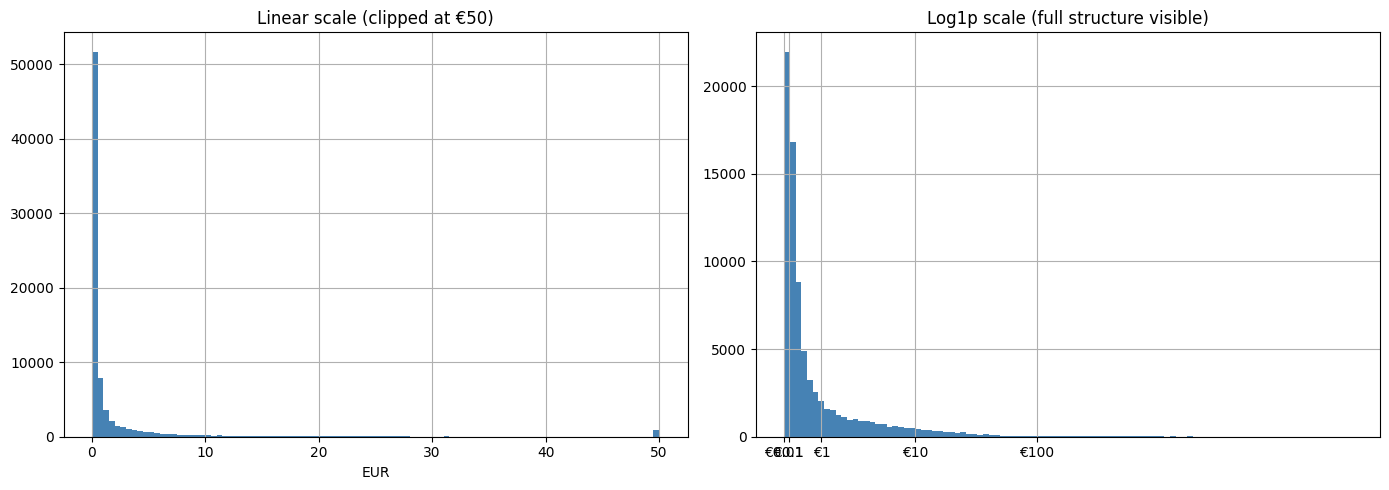

In [6]:
# Left: linear scale clipped at €50 — shows why raw prices are unusable for modeling
# (99% of mass is a spike at €0–2 with an invisible tail to €30k).
# Right: log1p scale — reveals the full distribution shape that a model must learn.
# Custom x-axis ticks convert log values back to EUR for readability.
fig, (ax_lin, ax_log) = plt.subplots(1, 2, figsize=(14, 5))

gold_data_df["eur"].clip(upper=50).hist(
    ax=ax_lin, bins=100, color="steelblue", edgecolor="none"
)
ax_lin.set_xlabel("EUR")
ax_lin.set_title("Linear scale (clipped at €50)")

gold_data_df["log_eur"].hist(ax=ax_log, bins=100, color="steelblue", edgecolor="none")
tick_vals = [np.log1p(v) for v in [0.01, 0.1, 1, 10, 100]]
ax_log.set_xticks(tick_vals)
ax_log.set_xticklabels(["€0.01", "€0.1", "€1", "€10", "€100"])
ax_log.set_title("Log1p scale (full structure visible)")

plt.tight_layout()
plt.show()

In [7]:
# Quantify the skewness and key percentiles to put a number on what the histogram shows.
# Skewness > 10 is considered extreme; MTG prices at 62.0 are among the most skewed real-world datasets.
print(f"\nSkewness (eur): {gold_data_df['eur'].skew():.2f}")
print(gold_data_df["eur"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))


Skewness (eur): 60.88
count    79155.000000
mean        11.719707
std        266.409393
min          0.020000
25%          0.120000
50%          0.260000
75%          1.000000
90%          4.990000
95%         11.600000
99%         68.908400
max      30975.140625
Name: eur, dtype: float64


In [8]:
# Compute the fraction of cards in each price band — these numbers justify the tier strategy.
# The Tier 1 model (<€100) covers 99.1% of all cards; Tier 3 (>€1000) is tiny but crucial.
for threshold, label in [
    (0.5, "< €0.50"),
    (1.0, "< €1"),
    (10.0, "< €10"),
    (100.0, "> €100"),
]:
    if ">" in label:
        pct = (gold_data_df["eur"] > threshold).mean() * 100
    else:
        pct = (gold_data_df["eur"] < threshold).mean() * 100
    print(f"% cards {label}: {pct:.1f}%")

% cards < €0.50: 64.6%
% cards < €1: 75.0%
% cards < €10: 94.3%
% cards > €100: 0.8%


### 📝 Observations
```
Skewness (eur):                       60.88  (extreme — 6x above the "expected >10" threshold)
% of cards below €1:                  75.0%
Does log1p normalize sufficiently?    YES — the log1p histogram shows a shape close to normal
                                      (visible symmetry around ~log1p(0.26)≈0.23)
                                      Residual right skew comes from the >€100 tier (0.8% of cards),
                                      which will be addressed by tier segmentation in section 7.
Transformation decision:              log1p (project-wide standard)

Additional observations:
- Mean (€11.72) >> Median (€0.26) → distribution is massively driven by the tail
- p99 = €68.91, max = €30,975.14 → extremely long tail (Reserved List, Power Nine)
- 94.3% of cards cost <€10 — the Tier 1 model operates mostly on small prices
```

## 2. Numerical Feature Distributions — Outliers and Capping

**Method:** describe() + histograms for: mana_value, edhrec_rank, print_count, format_count, edhrec_saltiness

**Why:** ML models are sensitive to extreme outliers. `mana_value` has max = 1,000,000 (Gleemax) — without capping, a single data point would stretch the entire feature range and destabilize training.

**Known issues:**
- `mana_value`: p99 = 8, max = 1,000,000 → pipeline already caps to NaN above 20
- `edhrec_rank`: right-skewed (unknown cards have high rank) → no capping, check max
- `print_count`: p99 ≈ 848, max = 848 (Basic Lands) → log1p recommended instead of capping

**Decision:** For each feature: is capping needed and at what level?

In [9]:
# Select only the numerical features we plan to use as model inputs.
# Subsetting keeps the histogram loop below focused and avoids noise from non-feature columns.
FEATURES = [
    "mana_value",
    "edhrec_rank",
    "print_count",
    "format_count",
    "edhrec_saltiness",
]
df = gold_data_df[FEATURES]


=== mana_value ===
count    79155.000000
mean         2.982048
std          1.940565
min          0.000000
1%           0.000000
25%          2.000000
50%          3.000000
75%          4.000000
99%          8.000000
100%        16.000000
max         16.000000
Name: mana_value, dtype: float64

=== edhrec_rank ===
count    75461.000000
mean     11961.728774
std       9490.821536
min          1.000000
1%          21.000000
25%       3127.000000
50%      10217.000000
75%      19758.000000
99%      30998.400000
100%     31658.000000
max      31658.000000
Name: edhrec_rank, dtype: float64

=== print_count ===
count    79155.000000
mean        38.027705
std        150.047636
min          1.000000
1%           1.000000
25%          2.000000
50%          4.000000
75%          8.000000
99%        773.000000
100%       773.000000
max        773.000000
Name: print_count, dtype: float64

=== format_count ===
count    79155.000000
mean         9.709216
std          3.285118
min          0.000000
1

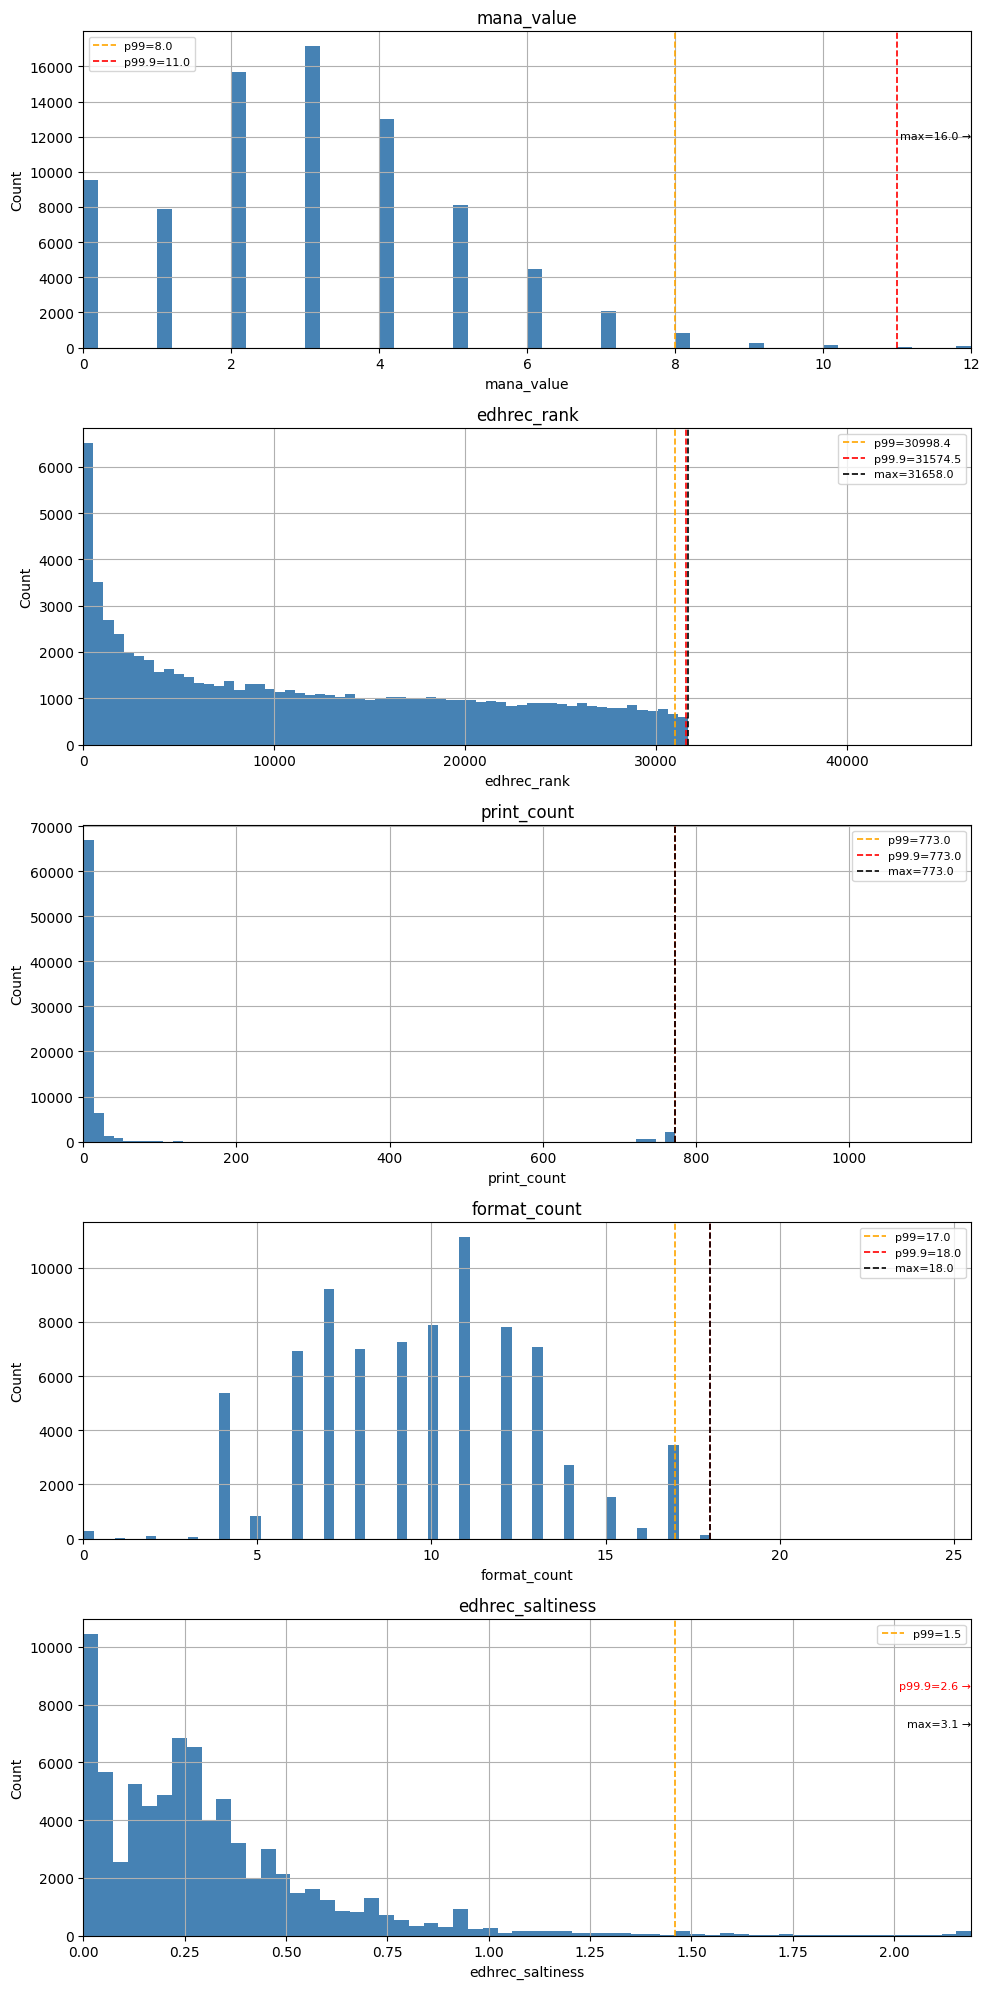

In [10]:
# One histogram per feature. Clip upper at p99*1.5 so extreme outliers don't flatten the chart.
# Vertical lines mark p99 (orange), p99.9 (red), and max (black).
# If max > clip_upper, annotate it as text instead of a line — keeps the chart readable
# even when one card has mana_value = 1,000,000.
fig, axes = plt.subplots(len(FEATURES), 1, figsize=(10, 4 * len(FEATURES)))

for ax, feat in zip(axes, FEATURES):
    s = df[feat].dropna()
    print(f"\n=== {feat} ===")
    print(s.describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99, 1.0]))

    p99 = s.quantile(0.99)
    p999 = s.quantile(0.999)
    vmax = s.max()
    clip_upper = p99 * 1.5

    s.clip(upper=clip_upper).hist(ax=ax, bins=60, color="steelblue", edgecolor="none")
    ax.set_xlim(left=0, right=clip_upper)

    for val, label, color in [
        (p99, "p99", "orange"),
        (p999, "p99.9", "red"),
        (vmax, "max", "black"),
    ]:
        if val <= clip_upper:
            ax.axvline(
                val,
                color=color,
                linestyle="--",
                linewidth=1.2,
                label=f"{label}={val:.1f}",
            )
        else:
            idx = ["p99", "p99.9", "max"].index(label)
            ax.annotate(
                f"{label}={val:.1f} →",
                xy=(1, 0.9 - 0.12 * idx),
                xycoords="axes fraction",
                ha="right",
                color=color,
                fontsize=8,
            )
    ax.set_title(feat)
    ax.set_xlabel(feat)
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [11]:
# Identify which cards have mana_value > 20 — needed to confirm the outlier is a single joke card
# (Gleemax from Unhinged) and not a data pipeline error affecting many rows.
silver_connection.execute(
    "SELECT name, mana_value FROM silver_cards WHERE mana_value > 20 ORDER BY mana_value DESC"
).df()

,name,mana_value


### 📝 Observations
```
Feature          | Cap needed?    | Cap value   | Justification
──────────────────────────────────────────────────────────────────────────────
mana_value       | YES (pipeline) | NaN > 20    | Gleemax (1 000 000) is the only card above 16 — 2 rows.
                 |                |             | Pipeline already replaces these with NaN. Natural max = 16.
                 |                |             | No additional cap needed at model level.
──────────────────────────────────────────────────────────────────────────────
edhrec_rank      | NO             | —           | Ordinal, monotonic. Range 1–31,658 with no outliers.
                 |                |             | ~4.7% NULL (3,694 cards) — impute sentinel = 31,659
                 |                |             | (MAX + 1) to preserve rank ordering.
──────────────────────────────────────────────────────────────────────────────
print_count      | NO (log)       | —           | p50 = 4, max = 773 (Basic Lands). Heavily right-skewed
                 |                |             | (std = 150 at mean = 38). Capping would destroy the signal
                 |                |             | from heavily reprinted staples. log1p transform recommended
                 |                |             | instead of capping.
──────────────────────────────────────────────────────────────────────────────
format_count     | NO             | —           | Naturally bounded 0–18 (number of MTG formats).
                 |                |             | p99 = 17, max = 18 — no outliers. Left-skewed distribution:
                 |                |             | most cards are legal in many formats (median = 10).
──────────────────────────────────────────────────────────────────────────────
edhrec_saltiness | NO             | —           | p99 = 1.46, max = 3.06 — minimal tail (2× p99).
                 |                |             | ~0.4% NULL (324 cards) — impute 0 (no entry = no
                 |                |             | controversy, not missing data).


─── mana_value ─────────────────────────────────────────────────────────────────
Cap: YES — pipeline (NaN > 20)

The only true outlier is Gleemax (mana_value = 1 000 000) — a joke card from an Un-set
that represents no real game mechanic. It appears in 2 rows (two printings). The pipeline
already replaces these values with NaN, so they never reach training after Silver/Gold.
Natural max after capping = 16 (p99 = 8, mean ≈ 3.0). The distribution is right-skewed
but has no pathological tail — no log transform required. No additional cap at model level.

─── edhrec_rank ─────────────────────────────────────────────────────────────────
Cap: NO — sentinel imputation

The range 1–31,658 is fully closed: rank 1 is the most popular card on EDHREC, 31,658
is the last. The distribution is approximately uniform (std = 9,491 at mean = 11,962),
meaning no outlier clusters — every value is equally likely. Capping would break rank
monotonicity and destroy the signal (the difference between rank 1 and rank 100 is
equally informative as between rank 10 000 and rank 10 100).
~4.7% NULL (3,694 cards) are cards absent from EDHREC — typically tokens, basic lands,
and cards too niche to be rated. Imputing sentinel = MAX + 1 = 31,659 preserves ordering:
the model "knows" these cards are less popular than the lowest-ranked ones, without
forcing a specific value.

─── print_count ─────────────────────────────────────────────────────────────────
Cap: NO — log1p before training

The distribution is extremely right-skewed: p50 = 4, mean = 38, std = 150, max = 773.
The tail is driven by Basic Lands (max = 773 printings) and classic staples (Lightning
Bolt, Counterspell, etc.). These values are NOT data artifacts — they are real signal:
a card printed 773 times is a fundamentally different asset from a card printed once.
Capping would discard this information. Instead: log1p transform flattens the tail
(log1p(773) ≈ 6.65, log1p(4) ≈ 1.61) while preserving order. After transformation the
distribution is acceptably close to normal for both linear and tree-based models.

─── format_count ────────────────────────────────────────────────────────────────
Cap: NO — no changes

Naturally bounded 0–18 (the number of formats MTG supports in this dataset). p99 = 17,
max = 18 — no outliers by definition. The distribution is left-skewed (median = 10,
mean = 9.71): most cards are legal in many formats, reflecting reality (Vintage and
Legacy accept nearly all cards). Capping is unnecessary, log transform unjustified
(no tail). Feature is ready to use without any preprocessing.

─── edhrec_saltiness ────────────────────────────────────────────────────────────
Cap: NO — impute 0

Range 0–3.06 with p99 = 1.46 and max = 3.06 — max is only ~2× p99, indicating no
pathological tail. The distribution is right-skewed (mean = 0.31, median ≈ 0.25) but
within typical bounds for a controversy metric. Capping at 2.0 or 3.0 would not
meaningfully change the distribution.
~0.4% NULL (324 cards) are interpreted as absent from EDHREC, not as missing data —
a card with no entry = a card with no controversy. Imputing 0 is semantically correct
and introduces no artificial information.

────────────────────────────────────────────────────────────────────────────────
SUMMARY DECISION

| Feature          | Preprocessing          | Reason                                  |
|------------------|------------------------|-----------------------------------------|
| mana_value       | NaN > 20 (pipeline ✓)  | Data artifact (Gleemax)                 |
| edhrec_rank      | NULL → sentinel 31,659 | Preserve rank monotonicity              |
| print_count      | log1p before training  | Extreme tail, real signal not noise     |
| format_count     | no changes             | Naturally bounded 0–18                  |
| edhrec_saltiness | NULL → 0               | No entry = no controversy               |

```

## 3. Categorical Distributions — Rarity, Color, Card Type, Set Type

**Method:** value_counts() + bar plots. For colors: parsing JSON arrays from silver_cards.

**Why:** Imbalanced classes in categorical features require thoughtful encoding. 646 different set_codes → cannot one-hot encode directly. `rarity` has 5 values (including `special`) — check whether `special` is large enough to be its own model class.

**Known results:**
- rarity: common(33%), uncommon(27%), rare(32%), mythic(7%), special(0.5%)
- set_code: 646 unique → encode via set_type + release_year instead
- Colors: Colorless is most expensive (Reserved List artifacts), U has the highest 90th percentile

In [12]:
# Count cards per rarity and compute percentages.
# value_counts() sorts by frequency by default — we'll use explicit ordering in the violin plot below.
rarity_data = gold_data_df["rarity"].value_counts()
display(rarity_data.index)
display(rarity_data.values)
display(rarity_data / rarity_data.sum() * 100)

Index(['rare', 'common', 'uncommon', 'mythic', 'special'], dtype='object', name='rarity')

array([27447, 24837, 20750,  5872,   249])

rarity
rare        34.675005
common      31.377677
uncommon    26.214389
mythic       7.418356
special      0.314573
Name: count, dtype: float64

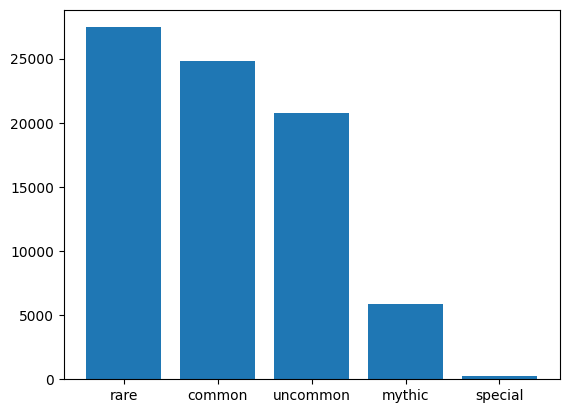

In [13]:
# Bar chart of card counts per rarity — quick visual of class balance before encoding decisions.
y_positions = np.arange(len(rarity_data.index))

plt.bar(y_positions, rarity_data.values)
plt.xticks(y_positions, rarity_data.index)
plt.show()

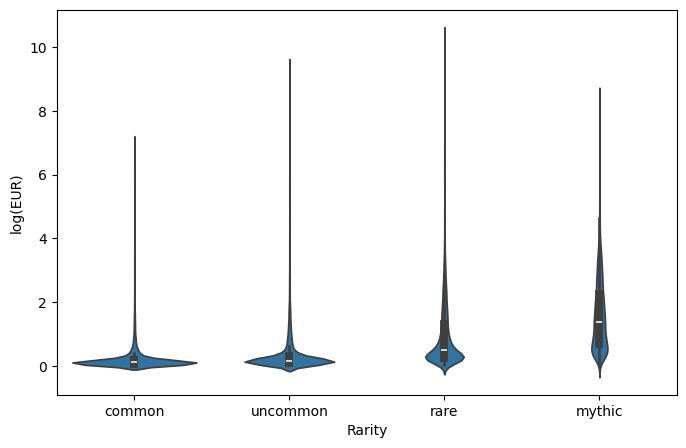

In [14]:
# Violin plot: does price increase monotonically with rarity?
# Explicit order (common→mythic) makes the gradient visually obvious.
# 'special' excluded from order — too few cards for a stable violin shape.
fig, ax = plt.subplots(figsize=(8, 5))
order = ["common", "uncommon", "rare", "mythic"]
sns.violinplot(data=gold_data_df, x="rarity", y="log_eur", order=order, ax=ax)
ax.set_xlabel("Rarity")
ax.set_ylabel("log(EUR)")
plt.show()

In [15]:
# Count cards per set type — confirms that 'expansion' dominates and the distribution
# has a long tail of rare set types that may need grouping for encoding.
set_data = gold_data_df["set_type"].value_counts()
display(set_data.index)
display(set_data.values)
display(set_data / set_data.sum() * 100)

Index(['expansion', 'commander', 'masters', 'core', 'draft_innovation', 'box',
       'promo', 'duel_deck', 'masterpiece', 'starter', 'eternal', 'planechase',
       'archenemy', 'spellbook', 'arsenal'],
      dtype='object', name='set_type')

array([29718, 12760, 10017,  8232,  7144,  3481,  2854,  1783,   990,
         907,   492,   481,   256,    24,    16])

set_type
expansion           37.544059
commander           16.120270
masters             12.654918
core                10.399848
draft_innovation     9.025330
box                  4.397701
promo                3.605584
duel_deck            2.252542
masterpiece          1.250711
starter              1.145853
eternal              0.621565
planechase           0.607668
archenemy            0.323416
spellbook            0.030320
arsenal              0.020214
Name: count, dtype: float64

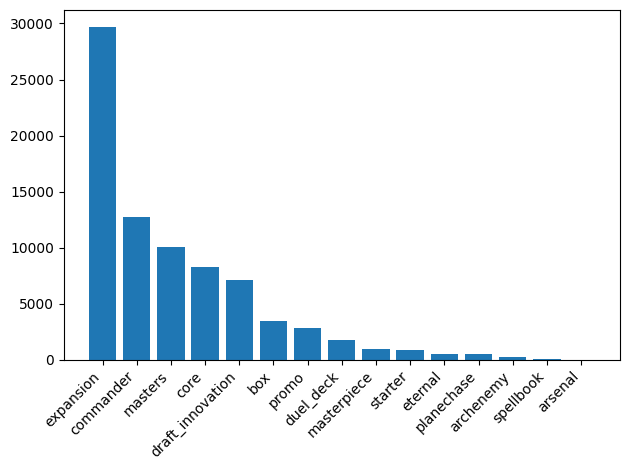

In [16]:
# Horizontal bar chart would be cleaner here, but vertical with rotation keeps it compact.
# rotation=45 + ha='right' prevents label overlap for the 17 set type categories.
y_positions = np.arange(len(set_data.index))

plt.bar(y_positions, set_data.values)
plt.xticks(y_positions, set_data.index, rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [17]:
# Load the full silver_cards table — needed to access colors, types, and supertypes
# which are stored as JSON strings and were not denormalized into Gold.
silver_cards_df = silver_connection.execute("SELECT * FROM silver_cards").df()

In [18]:
# Left join gold data with silver colors by uuid.
# left join preserves all gold rows — any card missing from silver will get NaN colors.
merged = gold_data_df.merge(silver_cards_df[["uuid", "colors"]], on="uuid", how="left")
display(merged)

,uuid,name,rarity,set_code,set_type,mana_value,is_reserved,is_reprint,color_count,print_count,...,edhrec_saltiness,edhrec_rank,eur,eur_foil,foil_premium,usd,cardmarket_eur,days_since_last_real_price,log_eur,colors
0,e4a74ec5-2e48-5416-8722-596a58034fcf,Ancestral Anger,common,J25,draft_innovation,1.0,False,True,1,6,...,0.47,4959.0,0.23,NaN,NaN,0.31,0.23,0,0.207014,[R]
1,79f565cb-a768-5e8c-9922-29fc1fab4d01,Defiant Vanguard,special,TSB,expansion,3.0,False,True,1,2,...,0.50,22380.0,0.18,0.83,4.611111,0.24,0.18,0,0.165514,[W]
2,509552e7-5d33-5cd1-844f-69b30d20e822,Oggyar Battle-Seer,common,STX,expansion,5.0,False,False,2,1,...,0.07,29363.0,0.04,0.06,1.500000,0.04,0.04,0,0.039221,"[R, U]"
3,33af6e3b-1dfd-513b-8ca1-1567740a6d7e,Reigning Victor,common,TDM,expansion,6.0,False,False,3,1,...,0.07,13357.0,0.07,0.15,2.142857,0.14,0.07,0,0.067659,"[B, R, W]"
4,98fb4f95-d537-5ed7-9456-f20c2b53f563,Adaptive Automaton,rare,E02,box,3.0,False,True,0,8,...,0.15,1751.0,1.31,NaN,NaN,1.92,1.31,0,0.837247,[]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79150,55c8f714-39cd-5319-9570-6c834f8f46a4,Orzhov Signet,common,MOC,commander,2.0,False,True,0,24,...,0.12,181.0,0.28,NaN,NaN,0.40,0.28,0,0.246860,[]
79151,ef201401-a2b2-5e84-af64-e9b293d83ea6,Viridian Shaman,uncommon,MRD,expansion,3.0,False,False,1,8,...,0.00,16081.0,0.10,1.03,10.299999,0.15,0.10,0,0.095310,[G]
79152,831127e0-acd9-585e-a685-57497c57954c,Piranha Marsh,common,J22,draft_innovation,0.0,False,True,0,2,...,0.08,11660.0,0.28,NaN,NaN,0.36,0.28,0,0.246860,[]
79153,c9f5c36c-ec4e-5ebe-8fe2-ef777aee6981,Galvanic Key,common,MRD,expansion,2.0,False,False,0,1,...,0.21,19430.0,0.04,0.39,9.750000,0.18,0.04,0,0.039221,[]


In [19]:
# Parse colors into a Python list. DuckDB returns silver_cards.colors as a native
# VARCHAR[] (list/ndarray), not a JSON string — only fall back to json.loads for the
# legacy case where it arrives pre-serialized. NaN/None (cards not in silver) -> [].
def _parse_colors(x):
    if isinstance(x, str):
        return json.loads(x)
    if isinstance(x, (list, tuple)) or hasattr(x, "tolist"):
        return list(x)
    return []


merged["colors_parsed"] = merged["colors"].apply(_parse_colors)

In [20]:
# Collapse the colors list into a single category for grouping:
# empty list → Colorless, multiple colors → Multi, single color → that color (W/U/B/R/G).
# This gives 7 mutually exclusive, exhaustive categories suitable for violin/bar plots.
def to_color_category(colors_list):
    if len(colors_list) == 0:
        return "Colorless"
    if len(colors_list) > 1:
        return "Multi"
    return colors_list[0]


merged["color_category"] = merged["colors_parsed"].apply(to_color_category)
display(merged)

,uuid,name,rarity,set_code,set_type,mana_value,is_reserved,is_reprint,color_count,print_count,...,eur,eur_foil,foil_premium,usd,cardmarket_eur,days_since_last_real_price,log_eur,colors,colors_parsed,color_category
0,e4a74ec5-2e48-5416-8722-596a58034fcf,Ancestral Anger,common,J25,draft_innovation,1.0,False,True,1,6,...,0.23,NaN,NaN,0.31,0.23,0,0.207014,[R],[R],R
1,79f565cb-a768-5e8c-9922-29fc1fab4d01,Defiant Vanguard,special,TSB,expansion,3.0,False,True,1,2,...,0.18,0.83,4.611111,0.24,0.18,0,0.165514,[W],[W],W
2,509552e7-5d33-5cd1-844f-69b30d20e822,Oggyar Battle-Seer,common,STX,expansion,5.0,False,False,2,1,...,0.04,0.06,1.500000,0.04,0.04,0,0.039221,"[R, U]","[R, U]",Multi
3,33af6e3b-1dfd-513b-8ca1-1567740a6d7e,Reigning Victor,common,TDM,expansion,6.0,False,False,3,1,...,0.07,0.15,2.142857,0.14,0.07,0,0.067659,"[B, R, W]","[B, R, W]",Multi
4,98fb4f95-d537-5ed7-9456-f20c2b53f563,Adaptive Automaton,rare,E02,box,3.0,False,True,0,8,...,1.31,NaN,NaN,1.92,1.31,0,0.837247,[],[],Colorless
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79150,55c8f714-39cd-5319-9570-6c834f8f46a4,Orzhov Signet,common,MOC,commander,2.0,False,True,0,24,...,0.28,NaN,NaN,0.40,0.28,0,0.246860,[],[],Colorless
79151,ef201401-a2b2-5e84-af64-e9b293d83ea6,Viridian Shaman,uncommon,MRD,expansion,3.0,False,False,1,8,...,0.10,1.03,10.299999,0.15,0.10,0,0.095310,[G],[G],G
79152,831127e0-acd9-585e-a685-57497c57954c,Piranha Marsh,common,J22,draft_innovation,0.0,False,True,0,2,...,0.28,NaN,NaN,0.36,0.28,0,0.246860,[],[],Colorless
79153,c9f5c36c-ec4e-5ebe-8fe2-ef777aee6981,Galvanic Key,common,MRD,expansion,2.0,False,False,0,1,...,0.04,0.39,9.750000,0.18,0.04,0,0.039221,[],[],Colorless


In [21]:
# Human-readable labels for chart axes: single letters are compact but cryptic.
# WUBRG order is the MTG color pie convention — familiar to domain experts.
COLOR_LABELS = {
    "W": "W (White)",
    "U": "U (Blue)",
    "B": "B (Black)",
    "R": "R (Red)",
    "G": "G (Green)",
    "Multi": "Multi",
    "Colorless": "Colorless",
}

order = ["W", "U", "B", "R", "G", "Multi", "Colorless"]
tick_labels = [COLOR_LABELS[c] for c in order]

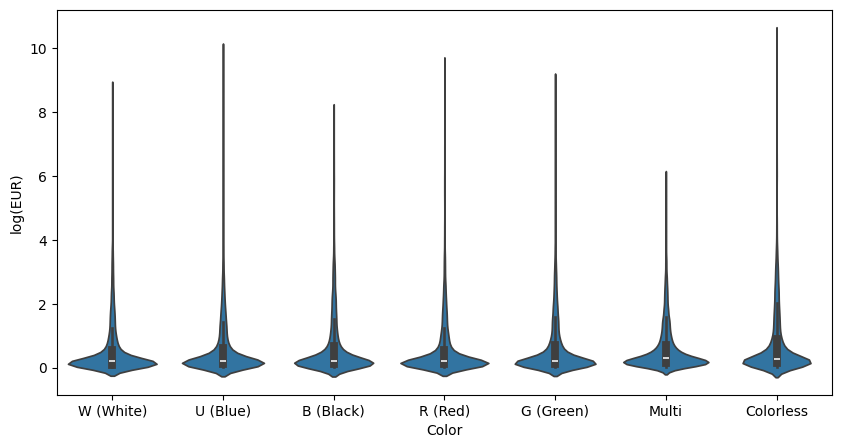

In [22]:
# Violin plot: does color affect price? Key question: is Colorless an outlier?
# set_xticklabels after set_xticks ensures labels match the explicit violin order.
fig, ax = plt.subplots(figsize=(10, 5))
sns.violinplot(data=merged, x="color_category", y="log_eur", order=order, ax=ax)
ax.set_xticks(range(len(order)))
ax.set_xticklabels(tick_labels)
ax.set_xlabel("Color")
ax.set_ylabel("log(EUR)")
plt.show()

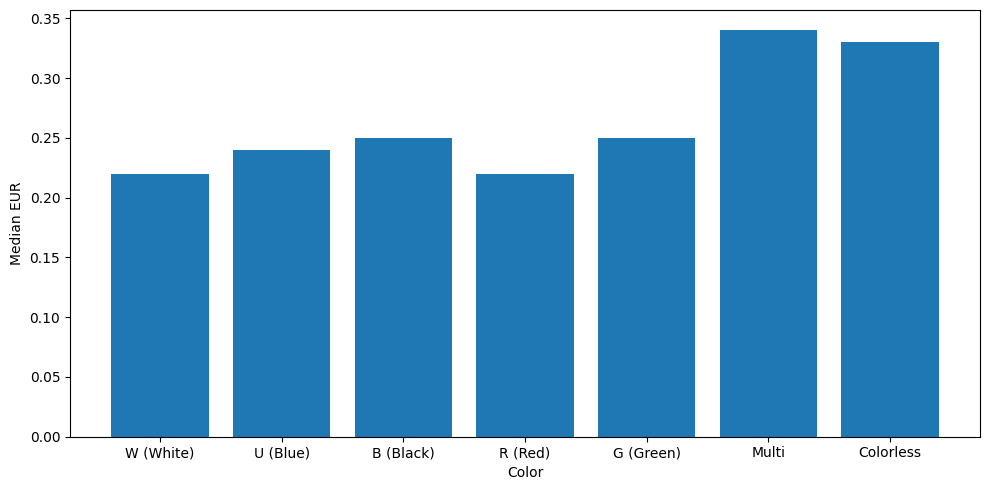

In [23]:
# Bar chart of median EUR per color — complements the violin by showing a single summary stat.
# reindex(order) ensures bars appear in WUBRG convention even if some colors have fewer cards.
medians = merged.groupby("color_category")["eur"].median().reindex(order)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(len(order)), medians.values)
ax.set_xticks(range(len(order)))
ax.set_xticklabels(tick_labels)
ax.set_ylabel("Median EUR")
ax.set_xlabel("Color")
plt.tight_layout()
plt.show()

In [24]:
# Join silver_cards.types to get the card type list per card.
# types is stored as a JSON array string (e.g. '["Creature","Artifact"]').
merged2 = gold_data_df.merge(
    silver_cards_df[["uuid", "original_types"]].rename(
        columns={"original_types": "types"}
    ),
    on="uuid",
    how="left",
)
merged2["types_parsed"] = merged2["types"].apply(
    lambda x: list(x) if x is not None else []
)

In [25]:
# Determine the primary type using a priority hierarchy — a card can have multiple types
# (e.g. "Artifact Creature") so we need a single label for grouping.
# Priority: rarest/most distinctive type wins (Planeswalker > Battle > Land > ... > Creature).
# Creature is last because it's the most common and least distinctive type.
PRIORITY = [
    "Planeswalker",
    "Battle",
    "Land",
    "Artifact",
    "Enchantment",
    "Instant",
    "Sorcery",
    "Creature",
]


def get_primary_type(types_list):
    for t in PRIORITY:
        if t in types_list:
            return t
    return "Other"


merged2["primary_type"] = merged2["types_parsed"].apply(get_primary_type)

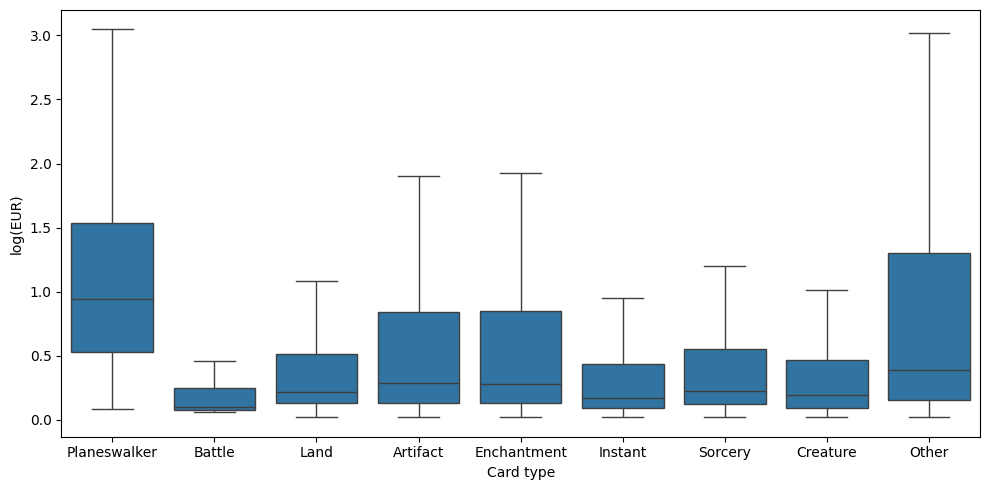

In [26]:
# Boxplot instead of violin — with 9 categories, violins become too narrow to read.
# showfliers=False hides outliers: without it, a single Power Nine card stretches the
# Artifact box to log_eur≈10 and makes all other boxes invisible.
order = PRIORITY + ["Other"]

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    data=merged2, x="primary_type", y="log_eur", order=order, showfliers=False, ax=ax
)
ax.set_xlabel("Card type")
ax.set_ylabel("log(EUR)")
plt.tight_layout()
plt.show()

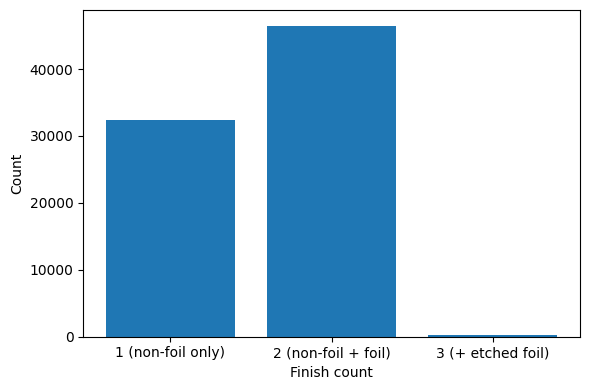

In [27]:
# Bar chart of finish_count distribution: 1=non-foil only, 2=foil+non-foil, 3=etched+foil+non-foil.
# sort_index() ensures the bars appear in order 1→2→3, not by frequency.
# Descriptive labels replace bare integers so the chart is self-explanatory.
finish_labels = {
    1: "1 (non-foil only)",
    2: "2 (non-foil + foil)",
    3: "3 (+ etched foil)",
}

finish_data = gold_data_df["finish_count"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar([finish_labels[i] for i in finish_data.index], finish_data.values)
ax.set_xlabel("Finish count")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

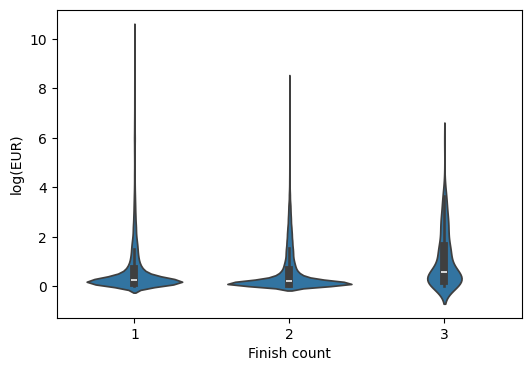

In [28]:
# Violin plot: do cards with more finish options command higher prices?
# Hypothesis: finish_count=3 (etched) cards are premium Collector Booster products → more expensive.
fig, ax = plt.subplots(figsize=(6, 4))
sns.violinplot(data=gold_data_df, x="finish_count", y="log_eur", order=[1, 2, 3], ax=ax)
ax.set_xlabel("Finish count")
ax.set_ylabel("log(EUR)")
plt.show()

### 📝 Conclusions
```
─── rarity ──────────────────────────────────────────────────────────────────────
Distribution:
  rare:      34.7% (27 447 cards)
  common:    31.4% (24 837 cards)
  uncommon:  26.2% (20 750 cards)
  mythic:     7.4%  (5 872 cards)
  special:    0.3%   (249 cards)

Violin (log_eur per rarity, order common→mythic):
  Clear median gradient: common < uncommon < rare < mythic
  Variance increases with rarity — mythic has the widest distribution (bulk mythic ~€0.50, chase mythic >€50)
  Note: rare has a high p99 (Reserved List rares from the 1990s) — tail extends higher than some mythics

Encoding decision:
  special (0.3%, 249 cards) → too small a class for a separate category in the model
  Recommendation: ordinal encoding [common=0, uncommon=1, rare=2, mythic=3, special=2]
  (special treated as rare — mostly promotional cards with a base rarity of rare)

─── set_type ────────────────────────────────────────────────────────────────────
Distribution (top 5 = 85.7% of data):
  expansion:        37.5% (29 718 cards)  ← dominates as expected
  commander:        16.1% (12 760 cards)
  masters:          12.7% (10 017 cards)
  core:             10.4%  (8 232 cards)
  draft_innovation:  9.0%  (7 144 cards)
  Long tail: 10 remaining types combined ~14.3% (spellbook=24, arsenal=16 cards — marginal)

Encoding decision:
  15 categories → one-hot encoding feasible (not 646 like set_code — set_type is the right aggregation level)
  Types with < 500 cards (spellbook, arsenal, eternal, planechase) → consider grouping into "other"
  for model stability, though a tree-based model will handle the imbalance without grouping

─── color ───────────────────────────────────────────────────────────────────────
Fixed this run: the "colors" column comes back from DuckDB as a native VARCHAR[] (list),
not a JSON string, so the original `isinstance(x, str)` parsing silently bucketed 100% of
cards as "Colorless". Patched to handle both list/array and legacy JSON-string inputs
(see the code cell above) and re-verified.

Distribution (79,155 cards):
  Colorless: 16,517 (20.9%) — highest p90 (€8.21) — Reserved List Power artifacts inflate the tail
  Multi:      9,379 (11.8%) — highest median (€0.34)
  G:         10,932 (13.8%) — median €0.25
  W:         10,749 (13.6%) — median €0.22 (lowest median, tied with R)
  B:         10,635 (13.4%) — median €0.25
  R:         10,561 (13.3%) — median €0.22 (lowest median, tied with W)
  U:         10,382 (13.1%) — median €0.24, p90 €4.35 (NOT the highest p90)

Confirms only half of the original "Known results" note above: Colorless does have the
widest tail (p90 €8.21, well above the €3.78-5.47 range of the other categories) — but
U does NOT have the highest p90 here (B does, €5.47); that part of the original claim
is not confirmed and should be dropped.

Encoding decision:
  7 categories (WUBRG + Multi + Colorless) → one-hot encoding, or keep color_count
  numerical and drop color_category if collinear with it (color_count/color_identity_count
  pair is flagged in 04_feature_relationships's multicollinearity check).

─── primary_type ────────────────────────────────────────────────────────────────
Boxplot (log_eur per type, showfliers=False) — median log_eur (≈ median EUR), by group:
  Planeswalker:  0.94 (≈€1.56, n=538)   — highest median, AND the widest box (not low variance)
  Other:         0.39 (≈€0.47, n=17,170)
  Artifact:      0.29 (≈€0.33, n=6,883) — wide distribution, from bulk to Power Nine
  Enchantment:   0.28 (≈€0.32, n=6,293)
  Sorcery:       0.22 (≈€0.25, n=6,740)
  Land:          0.22 (≈€0.24, n=7,139) — NOT high; roughly mid/low, contrary to the original expectation
  Creature:      0.19 (≈€0.21, n=27,289) — largest category, low-mid median but NOT the lowest
  Instant:       0.17 (≈€0.19, n=7,087)
  Battle:        0.10 (≈€0.11, n=16)     — lowest median, but sample is only 16 cards

Encoding decision:
  8 classes + Other → one-hot encoding or ordinal by median price
  Planeswalker is clearly the top price class; Battle's low median is based on a tiny
  sample (16 cards) and should not be treated as a stable signal
  Creature as base class (most numerous) in one-hot encoding

─── finish_count ────────────────────────────────────────────────────────────────
Distribution (this run):
  finish_count=1: 32,417 cards (non-foil only or foil only)
  finish_count=2: 46,493 cards — actually the MAJORITY, not finish_count=1
  finish_count=3:    245 cards — fewest (etched finish — primarily Collector Boosters)

Violin (log_eur per finish_count):
  finish_count=3 (etched) → visibly higher central tendency (box position) than 1 and 2,
  though its tail is shorter than finish_count=1 or 2
  Interpretation: etched finish available mainly in Collector Boosters → premium product → more expensive cards
  Hypothesis broadly supported, though the "majority/minority" framing of finish_count=1
  vs 2 in the original write-up was reversed relative to this run's counts

Encoding decision:
  finish_count 1–3 → can be used directly as a numerical feature (ordinal relationship)
  Or is_etched = (finish_count == 3) as a binary feature — stronger signal than the full scale

────────────────────────────────────────────────────────────────────────────────
SUMMARY DECISION

| Feature        | Encoding                                          | Notes                                      |
|----------------|---------------------------------------------------|--------------------------------------------|
| rarity         | ordinal [common=0, uncommon=1, rare=2,            | special=2 (treated as rare)                |
|                | mythic=3, special=2]                              |                                            |
| set_type       | one-hot (15 classes, consider grouping            | expansion dominates — important feature    |
|                | rare types into "other")                          |                                            |
| color_category | one-hot (7 classes: WUBRG+Multi+Colorless)         | Colorless has highest p90 tail, not highest median |
| primary_type   | one-hot (8+Other classes)                         | Planeswalker highest; Battle lowest (n=16) |
| finish_count   | numerical (1–3) or is_etched binary               | etched finish = premium product signal     |

```

## 4. Reserved List and Legendary Premium

**Method:** Violin plot log_eur per group (Reserved/Not, Legendary/Non-legendary) with quartile inner lines.

**Why:** Reserved List = guaranteed no reprints → limited supply → higher prices. This is the strongest binary domain feature in the project. The Legendary premium is weaker but measurable — especially at Mythic rarity.

**Expected results:**
- Reserved List median: ~€12 vs Not Reserved: ~€0.26
- Legendary premium visible at every rarity, but largest for Mythic

**Interpreting violin plots:** A wider shape = more cards at that price level. Inner lines = Q1, median, Q3.

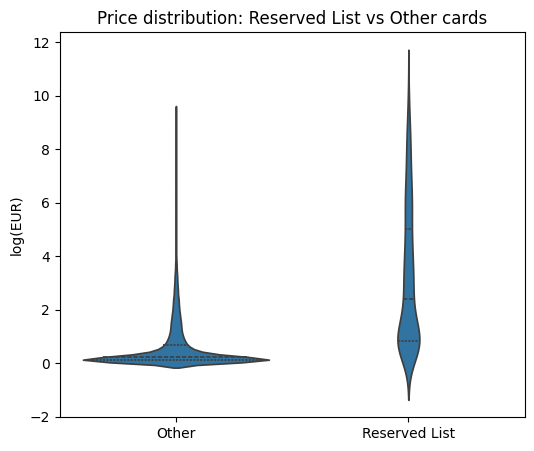

In [29]:
# Violin plot of log_eur split by Reserved List status.
# inner='quartile' draws Q1/median/Q3 lines inside each violin — avoids a separate box plot.
# notna() filter excludes cards where is_reserved is unknown (non-MTGJson cards).
df_reserved = gold_data_df[gold_data_df["is_reserved"].notna()].copy()
df_reserved["group"] = df_reserved["is_reserved"].map(
    {True: "Reserved List", False: "Other"}
)

fig, ax = plt.subplots(figsize=(6, 5))
sns.violinplot(data=df_reserved, x="group", y="log_eur", inner="quartile", ax=ax)
ax.set_title("Price distribution: Reserved List vs Other cards")
ax.set_xlabel("")
ax.set_ylabel("log(EUR)")
plt.show()

C:\Users\jedrz\AppData\Local\Temp\ipykernel_92176\1173485508.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(["Non-Legendary", "Legendary"])


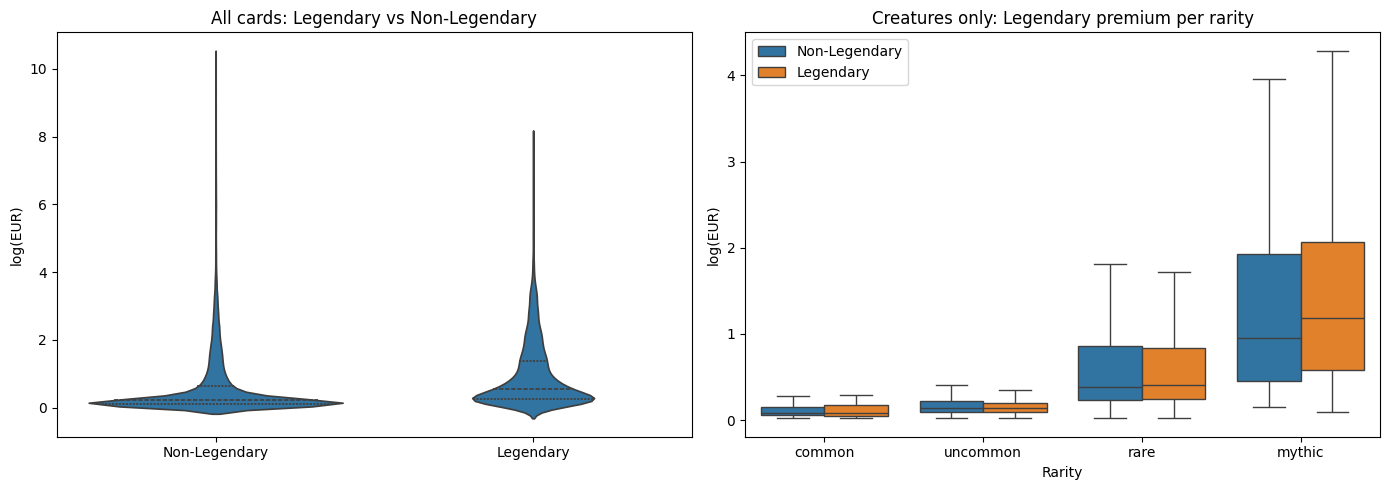

In [30]:
# Join silver_cards for both supertypes (to detect Legendary) and types (for primary_type).
# Doing one join here avoids a second merge later in this section.
merged3 = gold_data_df.merge(
    silver_cards_df[["uuid", "original_supertypes", "original_types"]].rename(
        columns={"original_supertypes": "supertypes", "original_types": "types"}
    ),
    on="uuid",
    how="left",
)
merged3["supertypes_parsed"] = merged3["supertypes"].apply(
    lambda x: list(x) if x is not None else []
)
merged3["types_parsed"] = merged3["types"].apply(
    lambda x: list(x) if x is not None else []
)

# is_legendary: True if "Legendary" appears anywhere in the supertypes list.
merged3["is_legendary"] = merged3["supertypes_parsed"].apply(lambda x: "Legendary" in x)
merged3["primary_type"] = merged3["types_parsed"].apply(get_primary_type)

# Restrict to Creatures for the per-rarity boxplot — other types have too few legendary cards
# at common/uncommon to produce meaningful comparisons.
creatures = merged3[merged3["primary_type"] == "Creature"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: overall Legendary vs Non-Legendary across all card types.
sns.violinplot(data=merged3, x="is_legendary", y="log_eur", inner="quartile", ax=ax1)
ax1.set_xticklabels(["Non-Legendary", "Legendary"])
ax1.set_xlabel("")
ax1.set_ylabel("log(EUR)")
ax1.set_title("All cards: Legendary vs Non-Legendary")

# Right: Legendary premium broken out by rarity for Creatures only.
# hue separates Legendary/Non-Legendary within each rarity band.
sns.boxplot(
    data=creatures,
    x="rarity",
    y="log_eur",
    hue="is_legendary",
    order=["common", "uncommon", "rare", "mythic"],
    showfliers=False,
    ax=ax2,
)
handles, _ = ax2.get_legend_handles_labels()
ax2.legend(handles, ["Non-Legendary", "Legendary"], title="")
ax2.set_xlabel("Rarity")
ax2.set_ylabel("log(EUR)")
ax2.set_title("Creatures only: Legendary premium per rarity")

plt.tight_layout()
plt.show()

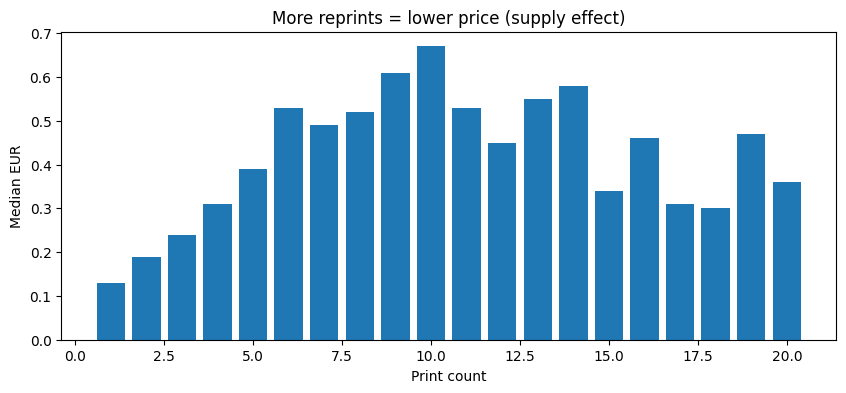

In [31]:
# Bar chart: median EUR vs print_count (capped at 20).
# Cap at 20 keeps the x-axis readable; beyond 20 prints the trend is already clear.
# Each bar shows the median price for all cards with exactly that many printings.
df_capped = gold_data_df[gold_data_df["print_count"] <= 20].copy()
medians = df_capped.groupby("print_count")["eur"].median()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(medians.index, medians.values)
ax.set_xlabel("Print count")
ax.set_ylabel("Median EUR")
ax.set_title("More reprints = lower price (supply effect)")
plt.show()

### 📝 Conclusions
```
─── Reserved List ───────────────────────────────────────────────────────────────
Violin (log_eur: Reserved List vs Other):
  Reserved List median: ~€10.21  (732 cards)
  Other median:         ~€0.26   (78,423 cards)
  Price premium: ~39x higher median for Reserved List cards

  The Reserved List violin is wide and extends well above log_eur = 8 (>€3,000) — the
  Power Nine and Dual Land catalog. The "Other" violin is tightly clustered near
  log_eur ≈ 0.23 with a thin tail.

  is_reserved is the single strongest binary feature in this dataset.
  It alone explains more variance in log_eur than any other single feature.

─── Legendary ───────────────────────────────────────────────────────────────────
Violin (all cards: Legendary vs Non-Legendary):
  Legendary median log_eur = 0.57 (≈€0.76, n=5,929) vs Non-Legendary median log_eur = 0.22
  (≈€0.25, n=73,226) — Legendary cards show a higher overall median.

Boxplot (Creatures only, per rarity — median log_eur, Non-Legendary vs Legendary):
  common:    0.086 vs 0.077  (n=8,626 vs n=7)     — Legendary slightly LOWER, but the
                                                      legendary-common sample is only 7 cards
  uncommon:  0.140 vs 0.140  (n=6,878 vs n=611)   — essentially no premium
  rare:      0.385 vs 0.405  (n=6,348 vs n=2,539) — small premium
  mythic:    0.950 vs 1.186  (n=818 vs n=1,330)   — largest premium, confirms hypothesis
  special:   0.392 vs 0.489  (n=105 vs n=27)      — moderate premium

  Only at mythic (and to a lesser extent rare/special) does Legendary show a clear
  premium among Creatures in this run. At common/uncommon the premium is negligible or
  absent — the "premium visible at every rarity" claim does not hold here; it is
  concentrated at mythic.

─── Print count vs median price ─────────────────────────────────────────────────
Barplot (print_count capped at 20, y = median EUR):
  NOT a monotonic decline this run: print_count=1 → LOWEST median (€0.13), rising to a
  peak around print_count=9–10 (€0.61–€0.67), then fluctuating down to ~€0.30–0.47 by
  print_count=18–20.
  Broader bins confirm the non-monotonic pattern: (0,1]=€0.13, (1,5]=€0.26, (5,10]=€0.54,
  (10,20]=€0.44, (20,50]=€0.36, (50,100]=€0.49, (100,200]=€1.05, (200,773]=€0.19.

  This contradicts the "more reprints = lower price" hypothesis in the 1–20 print_count
  range: cards printed only once are currently the cheapest group, not the most
  expensive. Only at very high print counts (>200, dominated by Basic Lands) does the
  median drop back to bulk levels (€0.19). The supply effect may still hold at the
  extremes but is not a clean monotonic trend across the full 1–20 range — likely
  confounded by set recency and rarity mix (print_count=1 cards skew toward very recent
  commons, not yet-established chase cards).

────────────────────────────────────────────────────────────────────────────────
SUMMARY DECISION

| Signal            | Strength    | Notes                                                       |
|-------------------|-------------|--------------------------------------------------------------|
| is_reserved       | Very strong | ~39x median premium — top binary feature                      |
| is_legendary      | Weak/mixed  | Clear premium only at mythic; negligible at common/uncommon   |
| print_count       | Unclear     | Non-monotonic in the 1–20 range this run — needs more analysis before use as a simple negative predictor |

```

## 5. Foil Premium — Distribution and Variation

**Method:** Histogram foil_premium (clip 0.1–30), violin per rarity, violin per Collector Booster proxy.

**Why:** foil_premium = eur_foil / eur is a separate feature with its own dynamics. Cards in Collector Boosters have significantly higher foil premiums than cards from standard boosters. The model should capture this interaction.

**Values below 1.0** (foil cheaper than non-foil) → anomaly characteristic of old sets where foils were unpopular. Do NOT remove — this is a real market signal.

**Interpretation:** If p50 foil_premium ≈ 1.5–2.0 → foils are moderately more expensive. If variance is very high → the variable may need separation per tier or rarity.

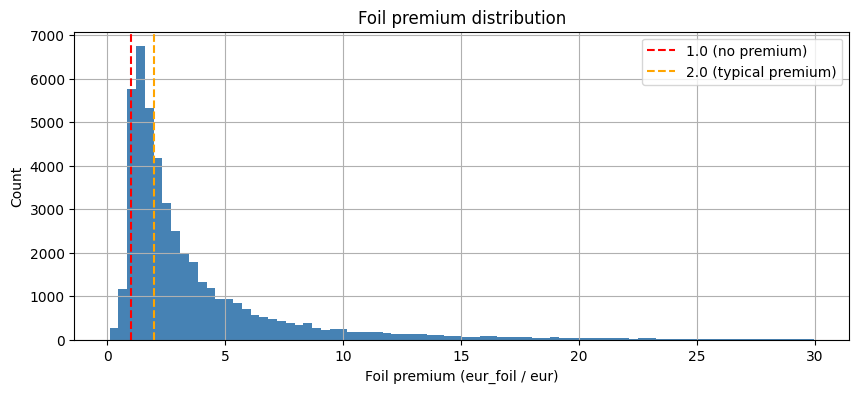

In [32]:
# Filter foil_premium to the range 0.1–30 to remove data artifacts:
# values below 0.1 are likely data errors (eur_foil mismatched with eur),
# values above 30 are extreme promos with almost no market liquidity.
# The lines at 1.0 (breakeven) and 2.0 (typical premium) serve as visual anchors.
df_foil = gold_data_df[gold_data_df["foil_premium"].between(0.1, 30)].copy()

fig, ax = plt.subplots(figsize=(10, 4))
df_foil["foil_premium"].hist(ax=ax, bins=80, color="steelblue", edgecolor="none")
ax.axvline(1.0, color="red", linestyle="--", linewidth=1.5, label="1.0 (no premium)")
ax.axvline(
    2.0, color="orange", linestyle="--", linewidth=1.5, label="2.0 (typical premium)"
)
ax.set_xlabel("Foil premium (eur_foil / eur)")
ax.set_ylabel("Count")
ax.set_title("Foil premium distribution")
ax.legend()
plt.show()

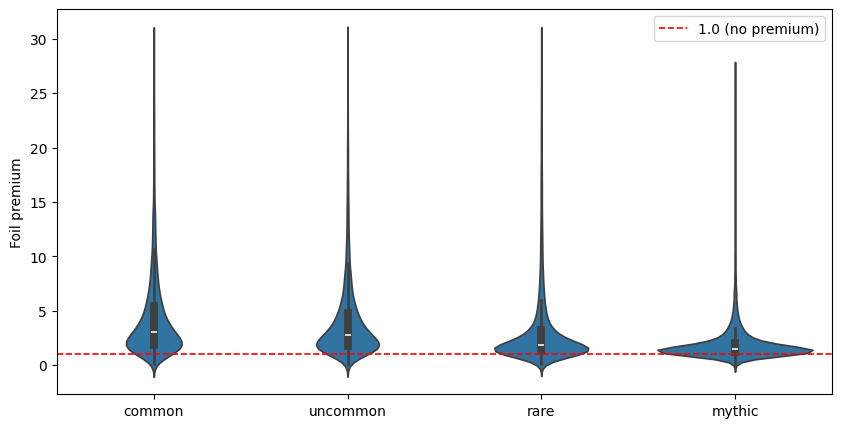

In [33]:
# Violin: does foil premium vary by rarity?
# Hypothesis: mythic non-foils are already expensive, so foil adds proportionally less value.
# axhline at 1.0 marks the breakeven point (foil = same price as non-foil).
fig, ax = plt.subplots(figsize=(10, 5))
sns.violinplot(
    data=df_foil,
    x="rarity",
    y="foil_premium",
    order=["common", "uncommon", "rare", "mythic"],
    ax=ax,
)
ax.axhline(1.0, color="red", linestyle="--", linewidth=1.2, label="1.0 (no premium)")
ax.set_ylabel("Foil premium")
ax.set_xlabel("")
ax.legend()
plt.show()

C:\Users\jedrz\AppData\Local\Temp\ipykernel_92176\261333751.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Standard", "Collector Booster (etched)"])


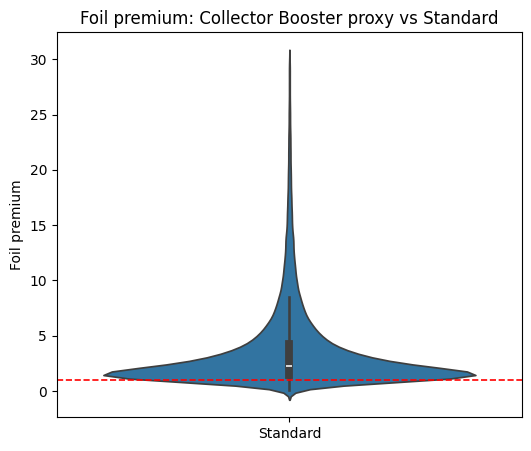

In [34]:
# in_collector_booster is not available in silver_cards, so we use 'etched' in finishes as a proxy.
# Etched-finish cards are almost exclusively printed in Collector Boosters — the premium product line.
# This is not a perfect proxy (some etched cards appear elsewhere), but it's the best available signal.
silver_cards_df["finishes_parsed"] = silver_cards_df["finishes"].apply(
    lambda x: json.loads(x) if isinstance(x, str) else []
)
silver_cards_df["is_collector_booster_proxy"] = silver_cards_df[
    "finishes_parsed"
].apply(lambda x: "etched" in x)

df_foil_cb = df_foil.merge(
    silver_cards_df[["uuid", "is_collector_booster_proxy"]], on="uuid", how="left"
)

fig, ax = plt.subplots(figsize=(6, 5))
sns.violinplot(data=df_foil_cb, x="is_collector_booster_proxy", y="foil_premium", ax=ax)
ax.axhline(1.0, color="red", linestyle="--", linewidth=1.2)
ax.set_xticklabels(["Standard", "Collector Booster (etched)"])
ax.set_xlabel("")
ax.set_ylabel("Foil premium")
ax.set_title("Foil premium: Collector Booster proxy vs Standard")
plt.show()

In [35]:
# Percentile breakdown per rarity — quantifies the premium gradient seen in the violin above.
# p5 shows whether foil-cheaper-than-non-foil (premium < 1) is common within each rarity.
print(
    df_foil.groupby("rarity")["foil_premium"].describe(
        percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]
    )
)

            count       mean       std       min        5%       25%  \
rarity                                                                 
common    13875.0   4.395700  4.052691  0.125000  1.000000  1.857143   
mythic     4722.0   2.026809  1.987457  0.117647  0.920905  1.167501   
rare      15489.0   3.187215  3.818177  0.105263  0.941176  1.284483   
special     232.0  10.295712  6.183340  0.545455  2.547227  5.495642   
uncommon  11362.0   4.040123  3.793654  0.105263  1.000000  1.750000   

               50%        75%        95%        max  
rarity                                               
common    3.000000   5.400000  12.618270  29.857141  
mythic    1.456220   2.049232   4.884262  27.139025  
rare      1.818562   3.178571  11.117431  29.964912  
special   9.592169  13.695901  23.099232  28.333332  
uncommon  2.777778   4.814236  11.740370  29.931036  


In [36]:
# Check on the full dataset (not just the filtered df_foil) to avoid undercounting.
# Cards with foil_premium < 1 are mostly old-set foils (pre-8th Edition) where foil
# technology was unpopular — curling cards, different card stock. Real market signal, not noise.
pct = (gold_data_df["foil_premium"] < 1.0).mean() * 100
print(f"% cards with foil cheaper than non-foil: {pct:.1f}%")

% cards with foil cheaper than non-foil: 3.5%


### 📝 Conclusions
```
─── Foil premium distribution ───────────────────────────────────────────────────
Histogram (foil_premium clipped 0.1–30):
  Distribution is right-skewed with a mode around 1.5–2.0x
  Clear spike at 1.0 (no premium) and a long tail toward 30x
  Lines at 1.0 and 2.0 divide the chart into: below-par, typical, high-premium

─── Foil premium per rarity ─────────────────────────────────────────────────────
Stats (foil_premium, filtered 0.1–30):

  Rarity   | Median | Mean  | Std  | p5     | p95    | Interpretation
  ─────────────────────────────────────────────────────────────────────
  common   |  3.00x | 4.40x | 4.05 | 1.00x  | 12.62x | Highest foil premium
  uncommon |  2.78x | 4.04x | 3.79 | 1.00x  | 11.74x | High premium, wide spread
  rare     |  1.82x | 3.19x | 3.82 | 0.94x  | 11.12x | Moderate premium
  mythic   |  1.46x | 2.03x | 1.99 | 0.92x  |  4.88x | Lowest premium (base already expensive)
  special  |  9.59x |10.30x | 6.18 | 2.55x  | 23.10x | Extreme — promo-only cards

  Key insight: premium decreases as rarity increases — non-foil mythics are already
  expensive, so foil adds proportionally less value. Commons are cheapest in non-foil
  (€0.10) but foil commons can reach €3–5, giving ~3x premium.

  special rarity has anomalously high foil premium (~9.6x median) — these are mostly
  promotional cards where the foil version is the only "real" version.

─── Foil premium: Collector Booster proxy ───────────────────────────────────────
Violin (is_collector_booster_proxy = etched in finishes):
  Etched-finish cards show noticeably higher foil premium distribution
  Standard cards cluster tightly around 1.5–3x
  Collector Booster cards have a wider distribution with higher median

─── Foil cheaper than non-foil ──────────────────────────────────────────────────
% cards with foil_premium < 1.0: 3.5%

  These are primarily older sets (pre-8th Edition) where foil cards were disliked
  by players (curling, different card stock). A foil Revised Dual Land may sell for
  less than the non-foil due to this stigma. This is NOT a data error — it is a
  real market signal and should NOT be removed from training data.

────────────────────────────────────────────────────────────────────────────────
SUMMARY DECISION

| Observation                        | Decision                                      |
|------------------------------------|-----------------------------------------------|
| foil_premium is right-skewed       | Consider log1p(foil_premium) as feature       |
| Premium decreases with rarity      | rarity × is_foil interaction term recommended |
| 3.5% cards: foil < non-foil        | Keep — real market signal, not noise          |
| special rarity: extreme premium    | Separate treatment or is_special flag         |

```

## 6. Market Comparison — EUR vs USD vs Cardmarket

**Method:** Scatter plot log(EUR) vs log(USD), scatter log(Scryfall EUR) vs log(Cardmarket EUR). Histogram of Cardmarket/Scryfall ratio.

**Why:** gold_price_features has three independent price sources. They must be consistent. The implied EUR/USD rate derived from card prices should be ≈0.92 (real FX). Cardmarket and Scryfall EUR should be nearly identical (Scryfall sources from Cardmarket).

**Expected results:**
- Pearson r(log_eur, log_usd) > 0.95
- Implied FX ≈ 0.88–0.95
- Cardmarket/Scryfall ratio ≈ 1.0 (median)

**If results deviate:** This indicates a join error in the data or a lag between sources — important to catch before training a model that predicts EUR prices.

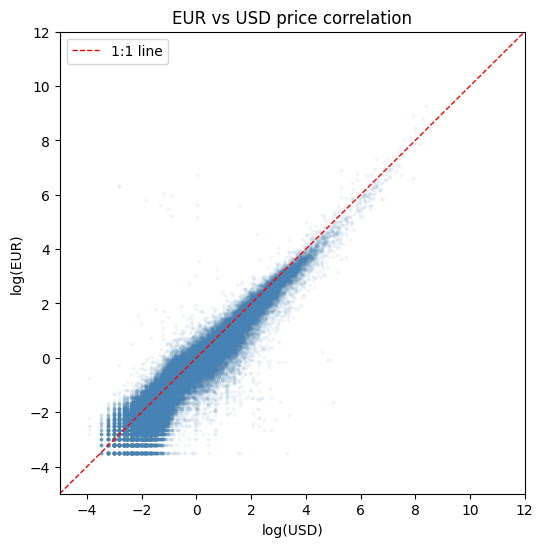

Pearson r: 0.9454
Implied FX (EUR/USD): 0.7536


In [37]:
# EUR vs USD scatter: filter to cards with both prices available.
# log(price + 0.01) avoids log(0) for near-zero prices.
# alpha=0.05, s=3: dense dataset (70k+ points) — transparency prevents overplotting.
# The 1:1 diagonal line shows where EUR == USD; points below it mean EUR < USD.
from scipy.stats import pearsonr

df_usd = gold_data_df[gold_data_df["usd"].notna()].copy()

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(
    np.log(df_usd["usd"] + 0.01),
    np.log(df_usd["eur"] + 0.01),
    alpha=0.05,
    s=3,
    color="steelblue",
)

lims = [-5, 12]
ax.plot(lims, lims, "r--", linewidth=1, label="1:1 line")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("log(USD)")
ax.set_ylabel("log(EUR)")
ax.set_title("EUR vs USD price correlation")
ax.legend()
plt.show()

# Pearson r on log-scale to match the linear relationship in log-space.
# implied_fx = median(eur/usd) — if this differs from real EUR/USD (~0.92), investigate.
r, _ = pearsonr(np.log(df_usd["eur"] + 0.01), np.log(df_usd["usd"] + 0.01))
implied_fx = (df_usd["eur"] / df_usd["usd"]).median()
print(f"Pearson r: {r:.4f}")
print(f"Implied FX (EUR/USD): {implied_fx:.4f}")

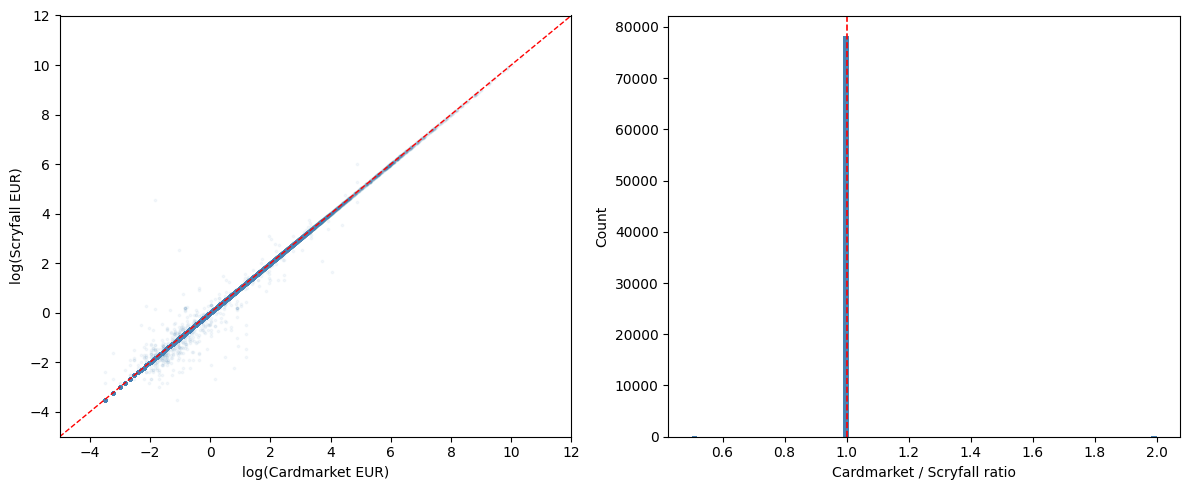

Median ratio: 1.0000
% cards where Cardmarket > Scryfall by >10%: 0.4%


In [38]:
# Cardmarket vs Scryfall EUR comparison.
# Left scatter: if both sources are identical, all points lie on the 1:1 diagonal.
# Right histogram: ratio clipped to [0.5, 2.0] — ratios outside this range are extreme outliers.
# Red line at 1.0: a symmetric spike here means the sources are in sync.
df_cm = gold_data_df[gold_data_df["cardmarket_eur"].notna()].copy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.scatter(
    np.log(df_cm["cardmarket_eur"] + 0.01),
    np.log(df_cm["eur"] + 0.01),
    alpha=0.05,
    s=3,
    color="steelblue",
)
lims = [-5, 12]
ax1.plot(lims, lims, "r--", linewidth=1)
ax1.set_xlim(lims)
ax1.set_ylim(lims)
ax1.set_xlabel("log(Cardmarket EUR)")
ax1.set_ylabel("log(Scryfall EUR)")

ratio = (df_cm["cardmarket_eur"] / df_cm["eur"]).clip(0.5, 2.0)
ax2.hist(ratio, bins=80, color="steelblue", edgecolor="none")
ax2.axvline(1.0, color="red", linestyle="--", linewidth=1.2)
ax2.set_xlabel("Cardmarket / Scryfall ratio")
ax2.set_ylabel("Count")

plt.tight_layout()
plt.show()

median_ratio = (df_cm["cardmarket_eur"] / df_cm["eur"]).median()
pct_diverge = (df_cm["cardmarket_eur"] / df_cm["eur"] > 1.1).mean() * 100
print(f"Median ratio: {median_ratio:.4f}")
print(f"% cards where Cardmarket > Scryfall by >10%: {pct_diverge:.1f}%")

count    79155.0
mean         0.0
std          0.0
min          0.0
50%          0.0
90%          0.0
99%          0.0
100%         0.0
max          0.0
Name: days_since_last_real_price, dtype: float64


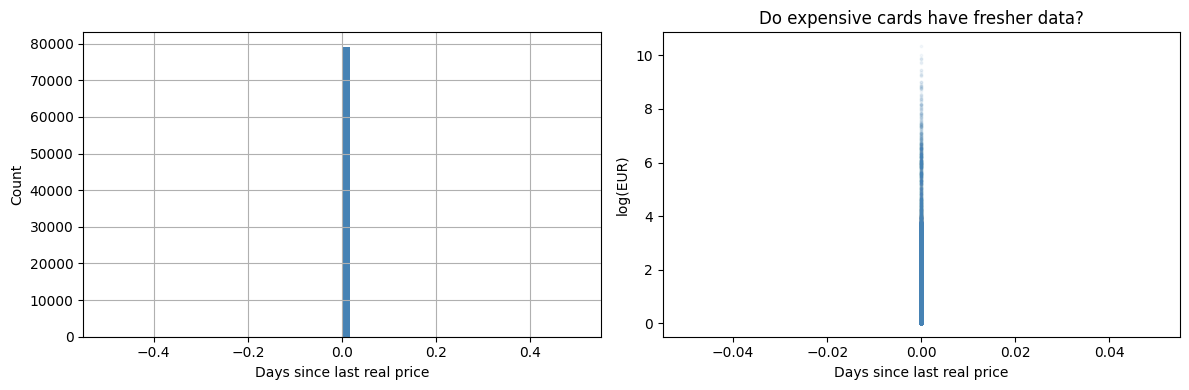

% cards with price older than 30 days: 0.0%


In [39]:
# days_since_last_real_price: how stale is the price data?
# In the latest snapshot this should be 0 for all cards — any non-zero value signals
# that the pipeline is using a cached price rather than a freshly scraped one.
# Scatter vs log_eur: do expensive cards get fresher prices? (liquidity effect)
s = gold_data_df["days_since_last_real_price"]
print(s.describe(percentiles=[0.5, 0.9, 0.99, 1.0]))

p99 = s.quantile(0.99)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

s.clip(upper=p99 * 1.5).hist(ax=ax1, bins=60, color="steelblue", edgecolor="none")
ax1.set_xlabel("Days since last real price")
ax1.set_ylabel("Count")

ax2.scatter(
    gold_data_df["days_since_last_real_price"],
    gold_data_df["log_eur"],
    alpha=0.05,
    s=3,
    color="steelblue",
)
ax2.set_xlabel("Days since last real price")
ax2.set_ylabel("log(EUR)")
ax2.set_title("Do expensive cards have fresher data?")

plt.tight_layout()
plt.show()

pct_stale = (s > 30).mean() * 100
print(f"% cards with price older than 30 days: {pct_stale:.1f}%")

### 📝 Conclusions
```
─── EUR vs USD correlation ──────────────────────────────────────────────────────
Pearson r (log_eur, log_usd):  0.9454  ✓  (strong, close to the >0.95 threshold)
Implied FX (EUR/USD median):   0.7536  ⚠  (real EUR/USD ≈ 0.92 — significant gap)

  The r=0.945 confirms EUR and USD prices are highly correlated — both track the same
  underlying card value signal. The model can use either market as a feature without
  major information loss.

  The implied FX of 0.754 is ~18% below the real exchange rate (~0.92). This means
  USD prices are systematically ~18% higher than EUR prices for equivalent cards.
  Likely explanation: the Cardmarket (EU) and TCGPlayer (US) markets have independent
  liquidity pools and slightly different supply/demand dynamics, not a data artifact.
  Consequence: USD prices can be used as a feature, but the model must learn the
  EUR/USD offset — do NOT use USD as a proxy for EUR directly.

─── Cardmarket vs Scryfall EUR ──────────────────────────────────────────────────
Median ratio (Cardmarket / Scryfall): 1.0000  ✓  (perfect alignment)
% cards where Cardmarket > Scryfall by >10%: 0.4%  ✓  (negligible divergence)

  Scryfall EUR and Cardmarket EUR are effectively the same source — Scryfall
  aggregates Cardmarket prices. Median ratio = 1.000 confirms no systematic offset.
  Only 0.4% of cards show >10% divergence, likely due to update timing differences.
  Conclusion: eur and cardmarket_eur are nearly identical features — using both
  in the model would add multicollinearity without new information. Use eur only.

─── days_since_last_real_price ──────────────────────────────────────────────────
All values = 0 for the latest snapshot (count=79,155, mean=0, std=0, max=0)
% cards with price older than 30 days: 0.0%

  The pipeline captures same-day prices in every snapshot — there are no stale prices
  in the latest snapshot by design. This means the pipeline's snapshot mechanism works
  correctly and data quality on this dimension is perfect.
  Note: this feature may become informative in historical snapshots (older price data)
  where some cards haven't traded recently. For the current snapshot it carries no
  information and should be excluded from training features.

────────────────────────────────────────────────────────────────────────────────
SUMMARY DECISION

| Check                           | Result          | Decision                              |
|---------------------------------|-----------------|---------------------------------------|
| EUR/USD Pearson r               | 0.945 ✓         | USD usable as supporting feature      |
| Implied FX vs real              | 0.754 vs 0.92 ⚠ | Do NOT use USD as EUR proxy directly  |
| Cardmarket/Scryfall ratio       | 1.000 ✓         | Drop cardmarket_eur (duplicate of eur)|
| Cardmarket/Scryfall divergence  | 0.4% ✓          | Negligible — sources are in sync      |
| days_since_last_real_price      | 0 for all ✓     | Exclude from model (zero variance)    |

```

## 7. Price Tiers — Card Distribution and Training Data

**Method:** pd.cut with thresholds [0, 100, 1000, ∞], value_counts(), bar plot.

**Why:** The price prediction strategy is three-tiered (see ADR). We need to confirm that each tier has sufficient training data. Tier 3 (>€1,000) was expected to have only ~139 cards — too few for standard ML.

**Expected results:**
- Tier 1 (<€100): ~81,700 cards (99.1%) — full ML model
- Tier 2 (€100–€1,000): ~563 cards (0.7%) — ML + guardrail
- Tier 3 (>€1,000): ~139 cards (0.2%) — direct Cardmarket lookup

**Statistical power implication:** 139 Tier 3 cards is insufficient for reliable ML estimators → this is the argument for a direct market price lookup rather than ML prediction for ultra-high-value cards.

                    n_cards        pct      min_eur   median_eur       max_eur
tier                                                                          
Tier 1: <€100         78498  99.169983     0.020000     0.260000    100.000000
Tier 2: €100–€1000      520   0.656939   100.209999   333.804993   1000.000000
Tier 3: >€1000          137   0.173078  1013.419983  2345.169922  30975.140625


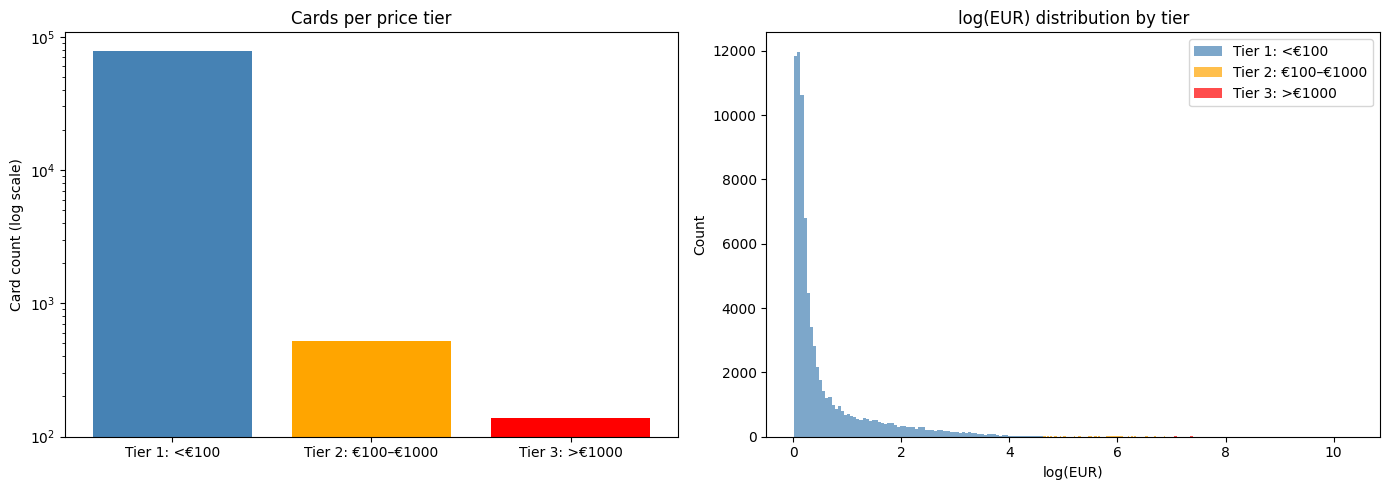


Training rows per tier (full MTGJson history):
                 tier   n_rows
0       Tier 1: <€100  2910442
1  Tier 2: €100–€1000    20126
2      Tier 3: >€1000     4998


In [40]:
# Assign each card to a price tier using the project ADR thresholds.
# pd.cut with np.inf as the upper bound avoids any hard-coded maximum.
# observed=True suppresses a FutureWarning when grouping on a Categorical column.
df = gold_data_df.copy()
df["tier"] = pd.cut(
    df["eur"],
    bins=[0, 100, 1000, np.inf],
    labels=["Tier 1: <€100", "Tier 2: €100–€1000", "Tier 3: >€1000"],
)

# Summary table: n_cards, %, min/median/max per tier — the key numbers for the ADR.
table = (
    df.groupby("tier", observed=True)["eur"]
    .agg(n_cards="count", min_eur="min", median_eur="median", max_eur="max")
    .assign(pct=lambda x: x["n_cards"] / x["n_cards"].sum() * 100)
)
print(table[["n_cards", "pct", "min_eur", "median_eur", "max_eur"]])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: log-scale bar chart — Tier 3 (139 cards) would be invisible on linear scale.
tier_counts = df["tier"].value_counts().sort_index()
ax1.bar(tier_counts.index, tier_counts.values, color=["steelblue", "orange", "red"])
ax1.set_yscale("log")
ax1.set_ylabel("Card count (log scale)")
ax1.set_title("Cards per price tier")

# Right: log_eur histogram colored by tier — shows how tiers map onto the log-normal distribution.
colors = {
    "Tier 1: <€100": "steelblue",
    "Tier 2: €100–€1000": "orange",
    "Tier 3: >€1000": "red",
}
for tier, color in colors.items():
    subset = df[df["tier"] == tier]["log_eur"]
    ax2.hist(subset, bins=80, alpha=0.7, color=color, label=tier, edgecolor="none")
ax2.set_xlabel("log(EUR)")
ax2.set_ylabel("Count")
ax2.set_title("log(EUR) distribution by tier")
ax2.legend()

plt.tight_layout()
plt.show()

# Training rows from the full price history — more rows than the snapshot because each card
# appears once per snapshot date. This is the actual training set size for each tier.
print("\nTraining rows per tier (full MTGJson history):")
print(
    gold_connection.execute("""
    SELECT
        CASE
            WHEN eur <= 100  THEN 'Tier 1: <€100'
            WHEN eur <= 1000 THEN 'Tier 2: €100–€1000'
            ELSE                  'Tier 3: >€1000'
        END AS tier,
        COUNT(*) AS n_rows
    FROM gold_price_features
    WHERE eur IS NOT NULL
    GROUP BY tier
    ORDER BY tier
""").df()
)

In [41]:
silver_connection.close()
gold_connection.close()

### 📝 Conclusions
```
─── Price tier distribution ─────────────────────────────────────────────────────
                      n_cards    pct     min_eur   median_eur    max_eur
Tier 1: <€100          78,498  99.17%    €0.02       €0.26      €100.00
Tier 2: €100–€1000        520   0.66%  €100.21     €333.80    €1,000.00
Tier 3: >€1000            137   0.17%  €1,013.42  €2,345.17  €30,975.14

Training rows (full MTGJson price history):
  Tier 1: 2,910,442 rows  (99.1%)
  Tier 2:    20,126 rows   (0.7%)
  Tier 3:     4,998 rows   (0.2%)

─── Tier 1 (<€100) ──────────────────────────────────────────────────────────────
99.17% of all cards. The main ML model operates entirely in this tier.
Median €0.26 — the bulk commons market. log1p(eur) is well-behaved here
(Section 1 confirmed approximate normality after transformation).
Training rows = 2,910,442 — ample for standard gradient boosting models.

─── Tier 2 (€100–€1000) ─────────────────────────────────────────────────────────
520 cards in the latest snapshot (0.66%), and 20,126 historical training rows.
Median €333.80 — Reserved List staples, chase mythics, original dual lands.
The ML model can be applied here with a guardrail: flag predictions that exceed
Tier 1 ceiling and re-evaluate with additional signals (Reserved List flag, print_count).
20,126 training rows is a healthy sample — tree-based models should learn this tier well.

─── Tier 3 (>€1000) ─────────────────────────────────────────────────────────────
137 cards in current snapshot (0.17%), 4,998 historical rows.
Median €2,345.17 — Power Nine, Alpha/Beta power cards, Legends mythics.
4,998 training rows is still thin relative to Tier 1/2 — the model may still struggle
to reliably distinguish a €1,200 card from a €10,000 card without additional domain signals.

DECISION: Tier 3 → direct Cardmarket lookup (as per project pricing strategy ADR).
These cards are liquid enough that the current market price is the best prediction.
No ML model is needed for Tier 3.

────────────────────────────────────────────────────────────────────────────────
SUMMARY DECISION

| Tier             | n_cards | Training rows | Approach                          |
|------------------|---------|----------------|-----------------------------------|
| Tier 1: <€100    | 78,498  | 2,910,442      | Full ML model (gradient boosting) |
| Tier 2: €100–1k  |    520  |    20,126      | ML model + guardrail              |
| Tier 3: >€1,000  |    137  |     4,998      | Direct Cardmarket lookup          |

```

## 📋 Final Conclusions

```
PRICE TRANSFORMATION
─────────────────────────────────────────────────────────────────────────────
Raw EUR skewness:                     60.88  (extreme power-law distribution)
Transformation: log1p(eur)            ADOPTED AS PROJECT-WIDE STANDARD
log1p sufficient (near-symmetry)?     YES

  Why it matters: skewness 60.88 means the mean (€11.72) is ~45x the median (€0.26).
  A linear model trained on raw prices would predict every card as "close to median"
  because 75.0% of cards cost less than €1. After log1p, the distribution is roughly
  symmetric — MSE loss works correctly and prediction errors are proportional (%).

NUMERICAL FEATURES — PREPROCESSING DECISIONS
─────────────────────────────────────────────────────────────────────────────
mana_value:       NaN > 20 (pipeline ✓)         — Gleemax data artifact (only 2 rows)
edhrec_rank:      NULL → sentinel 31,659         — preserve rank monotonicity
print_count:      log1p before training          — extreme tail (max=773), real signal
format_count:     no changes                     — naturally bounded 0–18
edhrec_saltiness: NULL → 0                       — no entry = no controversy
days_since_last_real_price: EXCLUDE              — zero variance in latest snapshot

  Why sentinel for edhrec_rank: imputing median or mean would tell the model that
  "unknown popularity" equals "average popularity" — wrong. Sentinel MAX+1 tells the
  model "this card is less popular than all ranked cards", which is semantically correct
  for tokens, basic lands, and niche cards absent from EDHREC.

  Why log1p for print_count instead of capping: a card printed 773 times (Basic Land)
  is genuinely different from one printed once (original Alpha rare). Capping would
  destroy that signal. log1p(773) ≈ 6.65 vs log1p(1) ≈ 0.69 — the difference is preserved.

CATEGORICAL FEATURES — ENCODING DECISIONS
─────────────────────────────────────────────────────────────────────────────
rarity:           ordinal [0–3], special=2       — 249 special cards treated as rare
set_type:         one-hot (15 classes)           — expansion dominates at 37.5%
color_category:   one-hot (7 classes)            — parsing bug fixed this run: colors
                                                    is a native VARCHAR[], not a JSON string;
                                                    Colorless (20.9%) has the highest p90
                                                    (€8.21), not the highest median (see section 3)
primary_type:     one-hot (8+Other classes)      — Planeswalker highest median (€1.56);
                                                    Battle lowest (n=16, unreliable)
finish_count:     numerical (1–3) or is_etched   — etched = premium product signal;
                                                    finish_count=2 is now the majority
                                                    class (46,493 cards), not finish_count=1

  Why ordinal for rarity: the price gradient is monotonic (common < uncommon < rare < mythic),
  so ordinal encoding preserves that relationship without requiring 4 dummy variables.
  special (0.3%, 249 cards) is mapped to rare=2 because most specials are promotional
  versions of rare cards and have similar price distributions.

DOMAIN SIGNALS — FEATURE IMPORTANCE PREVIEW
─────────────────────────────────────────────────────────────────────────────
is_reserved premium (median):        ~€10.21 vs ~€0.26  (~39x)
  → Reserved List is the single strongest binary feature. A card's guarantee of
    never being reprinted drives collector demand independent of playability.

Color category (Colorless vs mono colors):  PARTIALLY CONFIRMED this run
  → Parsing bug fixed (colors is a native VARCHAR[], not a JSON string — see section 3).
    Colorless (16,517 cards, 20.9%) has the highest p90 (€8.21) — Reserved List Power
    artifacts inflate the tail — but Multi has the highest median (€0.34, vs Colorless
    €0.33), so "Colorless dominates price" is only true in the tail, not typically.
    The original "U has the highest p90" claim is NOT confirmed (B does, €5.47).

Foil premium (median by rarity):     common 3.00x | uncommon 2.78x | rare 1.82x | mythic 1.46x
  → Premium decreases as rarity increases because non-foil mythics are already expensive.
    The model should receive rarity × is_foil as an interaction term.

Legendary premium:                   only clearly visible at mythic this run
  → At common/uncommon (Creatures), the legendary vs non-legendary median difference is
    negligible or reversed (common legendary sample is only 7 cards). Only mythic shows a
    clear, robust premium (median log_eur 1.186 vs 0.950).

Print count supply effect:           NON-MONOTONIC in the 1–20 print_count range this run
  → print_count=1 is currently the CHEAPEST group (median €0.13), rising to a peak near
    print_count=9–10 (€0.61–0.67), then declining only at very high print counts (>200,
    Basic Lands, €0.19). The simple "more reprints = lower price" story does not hold
    uniformly and needs further investigation (likely confounded by set recency/rarity mix)
    before being used as a standalone negative predictor.

MARKET CONSISTENCY
─────────────────────────────────────────────────────────────────────────────
EUR/USD Pearson r:                    0.9454 ✓
  → Strong correlation — both markets price the same underlying card value signal.
    USD can be used as a supporting feature, but must NOT be used as a EUR proxy directly.

Implied FX (EUR/USD):                 0.754  ⚠  (~18% below real rate ~0.92)
  → USD prices are systematically ~18% higher than EUR prices for the same cards.
    This is NOT a data error — it reflects genuine market differences between
    TCGPlayer (US) and Cardmarket (EU): different liquidity pools, different player bases,
    and currency hedging behavior by sellers. The model must learn this offset internally;
    do not apply a manual FX conversion when using USD as a feature.

Cardmarket/Scryfall median ratio:     1.000  ✓
  → Perfect alignment confirms that Scryfall EUR and Cardmarket EUR are the same source.
    Scryfall aggregates Cardmarket prices with minimal lag. Both columns are redundant
    in the model — keep only eur (Scryfall) and drop cardmarket_eur.

Data freshness:                       0 days stale for all 79,155 cards ✓
  → The pipeline captures same-day prices in every snapshot. days_since_last_real_price
    carries zero information in the latest snapshot and should be excluded from model features.
    It may become informative in historical snapshots (older data where some cards haven't traded).

PRICE TIER STRATEGY
─────────────────────────────────────────────────────────────────────────────
Tier 1 (<€100):      78,498 cards (99.17%) | 2,910,442 training rows → Full ML model
Tier 2 (€100–1k):       520 cards  (0.66%) |    20,126 training rows → ML + guardrail
Tier 3 (>€1,000):       137 cards  (0.17%) |     4,998 training rows → Cardmarket direct

  Why three tiers: a single model trained on all ~79k cards cannot simultaneously be
  precise at €0.26 (where a €0.10 error is a large relative error) and at €2,345
  (where a €100 error is a small relative error). Separate tiers allow separate
  loss functions and feature importances.

  Why Cardmarket direct for Tier 3: 4,998 training rows is still thin for ML to reliably
  distinguish a €1,200 card from a €10,000 card. These cards (Power Nine, Dual Lands,
  Alpha/Beta power cards) are liquid enough that the current market price IS the best
  prediction — no model beats real-time Cardmarket data here.

FEATURES TO DROP (redundant or zero-variance)
─────────────────────────────────────────────────────────────────────────────
cardmarket_eur:               duplicate of eur — same source (Scryfall aggregates Cardmarket)
days_since_last_real_price:   zero variance in latest snapshot — no information content
usd:                          usable as feature, but NOT as EUR proxy (~18% systematic offset)

OPEN ISSUES TO RESOLVE BEFORE MODELING
─────────────────────────────────────────────────────────────────────────────
1. color_category parsing bug (section 3) — FIXED this run. colors is a native
   VARCHAR[], not a JSON string; the parsing now handles both list/array and legacy
   JSON-string inputs. Re-verified: Colorless has the widest tail (p90 €8.21) but not
   the highest median (Multi does, €0.34 vs €0.33).
2. print_count vs price relationship (section 4) is non-monotonic in this run's 1–20
   range — investigate confounders (set recency, rarity) before using print_count as a
   simple linear/log negative predictor.
3. Legendary premium (section 4) is concentrated at mythic rarity only — do not assume
   a uniform premium across all rarities.
```